In [ ]:

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np



In [2]:

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)


Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)


In [3]:


x_train = x_train / 255.0
x_test = x_test / 255.0


In [ ]:

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']



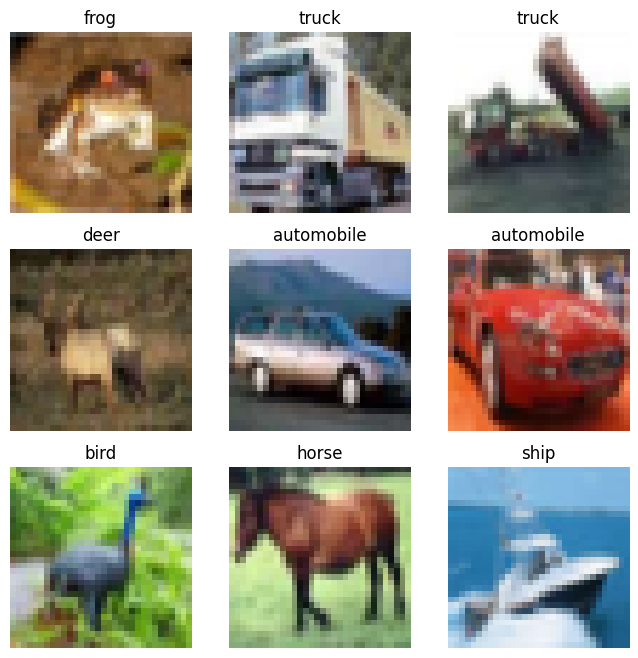

In [ ]:

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()


In [ ]:

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [8]:

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)



Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.4385 - loss: 1.5389 - val_accuracy: 0.5541 - val_loss: 1.2423
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5852 - loss: 1.1757 - val_accuracy: 0.5961 - val_loss: 1.1707
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6389 - loss: 1.0280 - val_accuracy: 0.6372 - val_loss: 1.0381
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6739 - loss: 0.9338 - val_accuracy: 0.6742 - val_loss: 0.9277
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6993 - loss: 0.8606 - val_accuracy: 0.6740 - val_loss: 0.9286
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7177 - loss: 0.8036 - val_accuracy: 0.6875 - val_loss: 0.9014
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7349 - loss: 0.7603 - val_accuracy: 0.6768 - val_loss: 0.9125
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7472 - lo

In [9]:

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6913 - loss: 0.9334
Test Accuracy: 0.6912999749183655


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


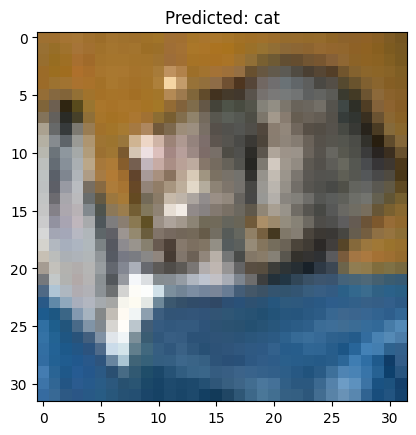

In [10]:

predictions = model.predict(x_test)

plt.imshow(x_test[0])
plt.title("Predicted: " + class_names[np.argmax(predictions[0])])
plt.show()

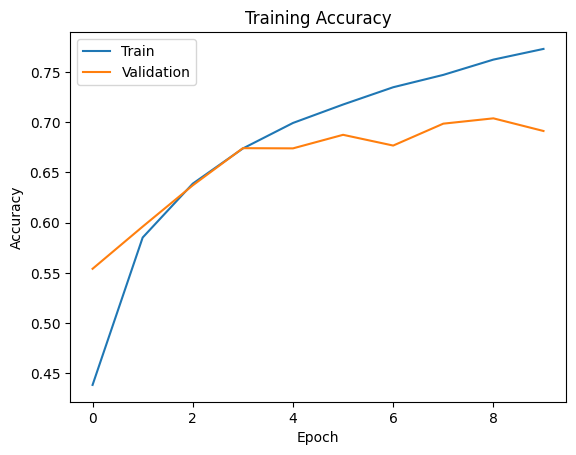

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.title('Training Accuracy')
plt.show()